
# Прогноз виручки за 7 днів для оцінки маркетингу.
**Розроблений прогноз має допомагати маркетологам якомога раніше і точніше приймати рішення**

**Дані:**
- `task_2_users_params.csv` — параметри користувачів при реєстрації + таргет `revenue_7d`
- `task_2_users_actions.csv` — дії користувачів за перший день (4 інтервали по 6 годин)

In [125]:
# Libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, classification_report, PrecisionRecallDisplay, precision_recall_curve, average_precision_score
from lightgbm import LGBMClassifier, LGBMRegressor

In [126]:
# Зчитуємо дані та оглядаємо
actions = pd.read_csv("../../data/task_2_users_actions.csv")
params = pd.read_csv("../../data/task_2_users_params.csv")

|------------------
# Поверхневий EDA



In [127]:
df_actions = actions.copy()
df_params = params.copy()

In [128]:
print("task_2_users_actions.csv: ")
print("Shape: ", df_actions.shape)
display(df_actions.head(3))

print("task_2_users_params.csv: ")
print("Shape: ", df_params.shape)
display(df_params.head(3))

task_2_users_actions.csv: 
Shape:  (6456848, 8)


,id_user,timestamp_interval_start,timestamp_interval_end,sum_payments,cnt_payments,sum_credits_spend,cnt_returns,cnt_visit_other_users
0,2672114,2024-08-20 07:07:14.493905+00:00,2024-08-20 13:07:14.493905+00:00,0.0,0,0,0,2
1,2672114,2024-08-20 13:07:14.493905+00:00,2024-08-20 19:07:14.493905+00:00,0.0,0,0,0,0
2,2672114,2024-08-20 19:07:14.493905+00:00,2024-08-21 01:07:14.493905+00:00,0.0,0,0,0,0


task_2_users_params.csv: 
Shape:  (1905428, 13)


,id_user,timestamp_reg,age,traffic_type_id,traffic_group_id,gender,country,device_browser,device_brand,device_model,device_platform,device_os,revenue_7d
0,1,2024-09-28 01:32:16.011076+00:00,53,1,1,male,CA,Mobile Silk,Amazon,Fire HD 10 (2021),tablet,Android,0.0
1,1,2024-09-28 01:32:16.011076+00:00,53,1,1,male,CA,Mobile Silk,Amazon,Fire HD 10 (2021),tablet,Android,0.0
2,13,2024-10-18 17:05:48.437175+00:00,53,1,7,male,US,Mobile Silk,Amazon,Fire HD 8 (2022),tablet,Android,0.0


In [129]:
# Детальна інформація по датасетам
df_actions.info(memory_usage='deep')
df_params.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 6456848 entries, 0 to 6456847
Data columns (total 8 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   id_user                   int64  
 1   timestamp_interval_start  str    
 2   timestamp_interval_end    str    
 3   sum_payments              float64
 4   cnt_payments              int64  
 5   sum_credits_spend         int64  
 6   cnt_returns               int64  
 7   cnt_visit_other_users     int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 1.3 GB
<class 'pandas.DataFrame'>
RangeIndex: 1905428 entries, 0 to 1905427
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id_user           int64  
 1   timestamp_reg     str    
 2   age               int64  
 3   traffic_type_id   int64  
 4   traffic_group_id  int64  
 5   gender            str    
 6   country           str    
 7   device_browser    str    
 8   device_brand      str    
 9   dev

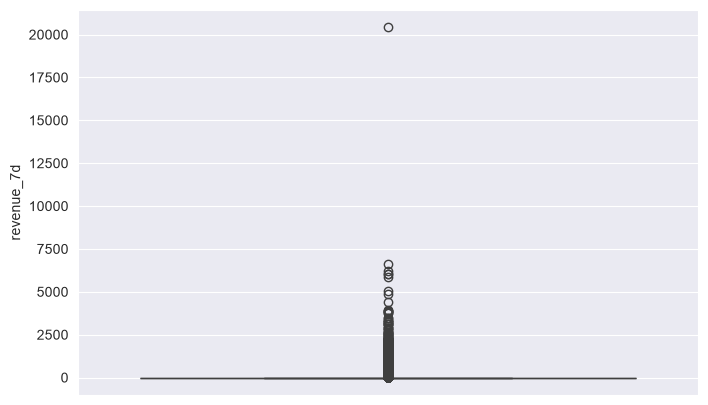

In [130]:
plt.figure(figsize=[8,5])
sns.boxplot(params['revenue_7d'])
plt.show()

In [131]:
miss_data_in_params = df_params.isnull().sum()
miss_data_in_actions = df_actions.isnull().sum()

print("Miss data(users_actions):\n",miss_data_in_actions,'\n')
print("Miss data(users_params):\n",miss_data_in_params, '\n')

print("Params shape:", df_params.shape)
print("Actions shape:", df_actions.shape)

print("Unique users in pairs:", df_params['id_user'].nunique())
print("Unique users in actions:", df_actions['id_user'].nunique())

Miss data(users_actions):
 id_user                     0
timestamp_interval_start    0
timestamp_interval_end      0
sum_payments                0
cnt_payments                0
sum_credits_spend           0
cnt_returns                 0
cnt_visit_other_users       0
dtype: int64 

Miss data(users_params):
 id_user                  0
timestamp_reg            0
age                      0
traffic_type_id          0
traffic_group_id         0
gender                   0
country               4345
device_browser        6861
device_brand        283445
device_model        181811
device_platform       6893
device_os             6861
revenue_7d               0
dtype: int64 

Params shape: (1905428, 13)
Actions shape: (6456848, 8)
Unique users in pairs: 1614200
Unique users in actions: 1614200


In [132]:
display(df_params[['age', 'revenue_7d']].describe())
display(df_actions[['sum_payments', 'cnt_payments', 'sum_credits_spend']].describe())

,age,revenue_7d
count,1.905428e+06,1.905428e+06
mean,4.804907e+01,1.099873e+00
std,1.682999e+01,3.259617e+01
min,0.000000e+00,0.000000e+00
25%,3.700000e+01,0.000000e+00
50%,5.300000e+01,0.000000e+00
75%,6.300000e+01,0.000000e+00
max,1.240000e+02,2.040958e+04


,sum_payments,cnt_payments,sum_credits_spend
count,6.456848e+06,6.456848e+06,6.456848e+06
mean,1.032068e-01,7.044459e-03,3.716503e+00
std,3.940898e+00,1.431226e-01,2.475382e+01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00
max,2.446800e+03,5.500000e+01,1.573000e+04


In [133]:
print(df_params['gender'].value_counts())
print(df_params['device_platform'].value_counts())

gender
male      1667485
female     237943
Name: count, dtype: int64
device_platform
mobile     1713627
desktop     145571
tablet       38154
tv             850
console        332
car              1
Name: count, dtype: int64


In [134]:
# Таргет — сильно скошений, більшість = 0
print('Всього рядків:', len(params))
print('revenue_7d == 0:', (params['revenue_7d'] == 0).sum())
print('revenue_7d > 0:', (params['revenue_7d'] > 0).sum())
print()
print(params['revenue_7d'].describe())

Всього рядків: 1905428
revenue_7d == 0: 1865898
revenue_7d > 0: 39530

count    1.905428e+06
mean     1.099873e+00
std      3.259617e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.040958e+04
Name: revenue_7d, dtype: float64


Велика кількість нулів, наша регресійна модель не зможе прогнозувати, бо багато однакових значень, так наша модель буде більше тягнути прогнозовані дані до нуля.

In [135]:
# Топ країни за середньою виручкою
country_revenue = (
    params.groupby('country')['revenue_7d']
    .agg(['mean', 'sum', 'count'])
    .sort_values('mean', ascending=False)
    .head(15)
)
country_revenue

,mean,sum,count
country,,,
NF,64.980000,64.98,1
GP,10.106928,1546.36,153
MC,9.360800,234.02,25
GU,5.388336,2979.75,553
PF,4.319393,924.35,214
IS,3.419638,2643.38,773
CH,3.051354,6041.68,1980
TC,2.783793,322.92,116
NO,2.520922,8964.40,3556


In [136]:
# Revenue по traffic_type
params.groupby('traffic_type_id')['revenue_7d'].agg(['mean', 'sum', 'count'])

,mean,sum,count
traffic_type_id,,,
1,0.803578,795105.40,989457
2,1.470265,1187296.26,807539
3,1.045147,113327.38,108432


In [137]:
# Revenue по device_platform
params.groupby('device_platform')['revenue_7d'].agg(['mean', 'sum', 'count']).sort_values('mean', ascending=False)

,mean,sum,count
device_platform,,,
desktop,1.849720,269265.61,145571
tablet,1.367464,52174.24,38154
mobile,1.029381,1763975.48,1713627
tv,0.035412,30.10,850
console,0.019578,6.50,332
car,0.000000,0.00,1


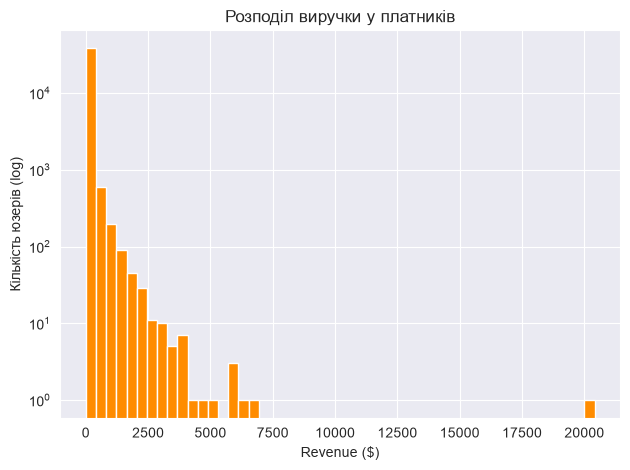

Медіана виручки у платників: $9.99
75-й перцентиль: $26.49
95-й перцентиль: $209.98
99-й перцентиль: $842.03
Максимум: $20409.58


In [138]:
# Розподіл виручки тільки серед тих, хто заплатив
payers = params[params['revenue_7d'] > 0]['revenue_7d']

plt.title('Розподіл виручки у платників')
plt.xlabel('Revenue ($)')
plt.ylabel('Кількість юзерів (log)')
plt.hist(payers, bins=50, color='darkorange', edgecolor='white', log=True)

plt.tight_layout()
plt.show()

print(f'Медіана виручки у платників: ${payers.median():.2f}')
print(f'75-й перцентиль: ${payers.quantile(0.75):.2f}')
print(f'95-й перцентиль: ${payers.quantile(0.95):.2f}')
print(f'99-й перцентиль: ${payers.quantile(0.99):.2f}')
print(f'Максимум: ${payers.max():.2f}')


-------------------
# Feature Engineering

In [139]:
# Переведемо часові фічі в потрібний нам формат
df_params['timestamp_reg'] = pd.to_datetime(
    df_params['timestamp_reg'],
    format='mixed'
)

df_actions['timestamp_interval_start'] = pd.to_datetime(
    df_actions['timestamp_interval_start'],
    format='mixed'
)

df_actions['timestamp_interval_end'] = pd.to_datetime(
    df_actions['timestamp_interval_end'],
    format='mixed'
)

In [140]:
# Видалення дублікатів.
print("Duplicate: ", df_params.duplicated().sum())
print("Duplicate: ", df_actions.duplicated().sum())

df_actions = df_actions.drop_duplicates()
df_params = df_params.sort_values('timestamp_reg').drop_duplicates(subset='id_user', keep='first')

print("After delete duplicate: ", df_params.duplicated().sum())
print("After delete duplicate: ", df_actions.duplicated().sum())
print("Now lines in params:", df_params.shape[0])

Duplicate:  291127
Duplicate:  39
After delete duplicate:  0
After delete duplicate:  0
Now lines in params: 1614200


In [141]:
df_actions.head(8)

,id_user,timestamp_interval_start,timestamp_interval_end,sum_payments,cnt_payments,sum_credits_spend,cnt_returns,cnt_visit_other_users
0,2672114,2024-08-20 07:07:14.493905+00:00,2024-08-20 13:07:14.493905+00:00,0.0,0,0,0,2
1,2672114,2024-08-20 13:07:14.493905+00:00,2024-08-20 19:07:14.493905+00:00,0.0,0,0,0,0
2,2672114,2024-08-20 19:07:14.493905+00:00,2024-08-21 01:07:14.493905+00:00,0.0,0,0,0,0
3,2672114,2024-08-21 01:07:14.493905+00:00,2024-08-21 07:07:14.493905+00:00,0.0,0,0,0,0
4,4314012,2024-08-20 07:07:25.610218+00:00,2024-08-20 13:07:25.610218+00:00,0.0,0,0,0,4
5,4314012,2024-08-20 13:07:25.610218+00:00,2024-08-20 19:07:25.610218+00:00,0.0,0,0,0,0
6,4314012,2024-08-20 19:07:25.610218+00:00,2024-08-21 01:07:25.610218+00:00,0.0,0,0,0,0
7,4314012,2024-08-21 01:07:25.610218+00:00,2024-08-21 07:07:25.610218+00:00,0.0,0,0,0,0


In [142]:
# Агрегуємо actions по юзеру
# Кожен юзер має 4 інтервали (6-годинні) => агрегуємо суми та розраховуємо поведінкові фічі
actions_agg = df_actions.groupby('id_user').agg(
    act_sum_payments=('sum_payments', 'sum'),
    act_max_payments=('sum_payments', 'max'),
    act_cnt_payments=('cnt_payments', 'sum'),
    act_sum_credits=('sum_credits_spend', 'sum'),
    act_cnt_returns=('cnt_returns', 'sum'),
    act_sum_visits=('cnt_visit_other_users', 'sum'),
    act_max_visits=('cnt_visit_other_users', 'max'),
    # Чи була активність взагалі у другому/третьому/четвертому інтервалі
    act_active_intervals=('cnt_visit_other_users', lambda x: (x > 0).sum()),
).reset_index()

print(actions_agg.shape)
actions_agg.head()

(1614200, 9)


,id_user,act_sum_payments,act_max_payments,act_cnt_payments,act_sum_credits,act_cnt_returns,act_sum_visits,act_max_visits,act_active_intervals
0,1,0.0,0.0,0,0,0,0,0,0
1,13,0.0,0.0,0,0,0,1,1,1
2,15,0.0,0.0,0,0,0,0,0,0
3,16,0.0,0.0,0,160,0,0,0,0
4,19,0.0,0.0,0,101,0,0,0,0


In [143]:
# З'єднуємо дві таблиці по ключу "id_user". (LEFT JOIN)
df = df_params.merge(actions_agg, on='id_user', how='left')

-----------------
# Підготовка для моделювання. Обробка фінального датасету

In [144]:
print('Shape:', df.shape, '\n')
print('Miss data:\n', df.isnull().sum(), '\n')
print('Duplicate: ', df.duplicated().sum())
display(df.head(3))

Shape: (1614200, 21) 

Miss data:
 id_user                      0
timestamp_reg                0
age                          0
traffic_type_id              0
traffic_group_id             0
gender                       0
country                   3790
device_browser            6861
device_brand            248046
device_model            167566
device_platform           6887
device_os                 6861
revenue_7d                   0
act_sum_payments             0
act_max_payments             0
act_cnt_payments             0
act_sum_credits              0
act_cnt_returns              0
act_sum_visits               0
act_max_visits               0
act_active_intervals         0
dtype: int64 

Duplicate:  0


,id_user,timestamp_reg,age,traffic_type_id,traffic_group_id,gender,country,device_browser,device_brand,device_model,...,device_os,revenue_7d,act_sum_payments,act_max_payments,act_cnt_payments,act_sum_credits,act_cnt_returns,act_sum_visits,act_max_visits,act_active_intervals
0,33861,2024-08-01 00:00:01.423192+00:00,23,1,1,male,NZ,NaN,NaN,NaN,...,NaN,0.0,0.0,0.0,0,0,0,1,1,1
1,67459,2024-08-01 00:00:05.687805+00:00,21,1,7,male,US,NaN,NaN,NaN,...,NaN,0.0,0.0,0.0,0,127,0,8,6,2
2,174142,2024-08-01 00:00:06.062047+00:00,23,1,1,male,US,NaN,NaN,NaN,...,NaN,0.0,0.0,0.0,0,0,0,1,1,1


In [145]:
# Створюємо нові фічі, які пов'язані з часом. Початкову колонку видаляємо
df['reg_hour'] = df['timestamp_reg'].dt.hour
df['reg_dayofweek'] = df['timestamp_reg'].dt.dayofweek
df['reg_is_weekend'] = (df['reg_dayofweek'] >= 5).astype(int)
df = df.drop('timestamp_reg', axis=1) # В нас вже масив відсортований, тому ця колонка не несе ніякої користі. Перед розбиттям на вибірки, нам не можна використовувати SHUFFLE.

In [146]:
# Ми вибираємо всі str колонки, заповнюємо пустоти та переводимо в category тип.
str_col = df.select_dtypes('str').columns
df[str_col] = df[str_col].fillna('unknown').astype('category')

In [147]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 1614200 entries, 0 to 1614199
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   id_user               1614200 non-null  int64   
 1   age                   1614200 non-null  int64   
 2   traffic_type_id       1614200 non-null  int64   
 3   traffic_group_id      1614200 non-null  int64   
 4   gender                1614200 non-null  category
 5   country               1614200 non-null  category
 6   device_browser        1614200 non-null  category
 7   device_brand          1614200 non-null  category
 8   device_model          1614200 non-null  category
 9   device_platform       1614200 non-null  category
 10  device_os             1614200 non-null  category
 11  revenue_7d            1614200 non-null  float64 
 12  act_sum_payments      1614200 non-null  float64 
 13  act_max_payments      1614200 non-null  float64 
 14  act_cnt_payments      1614200

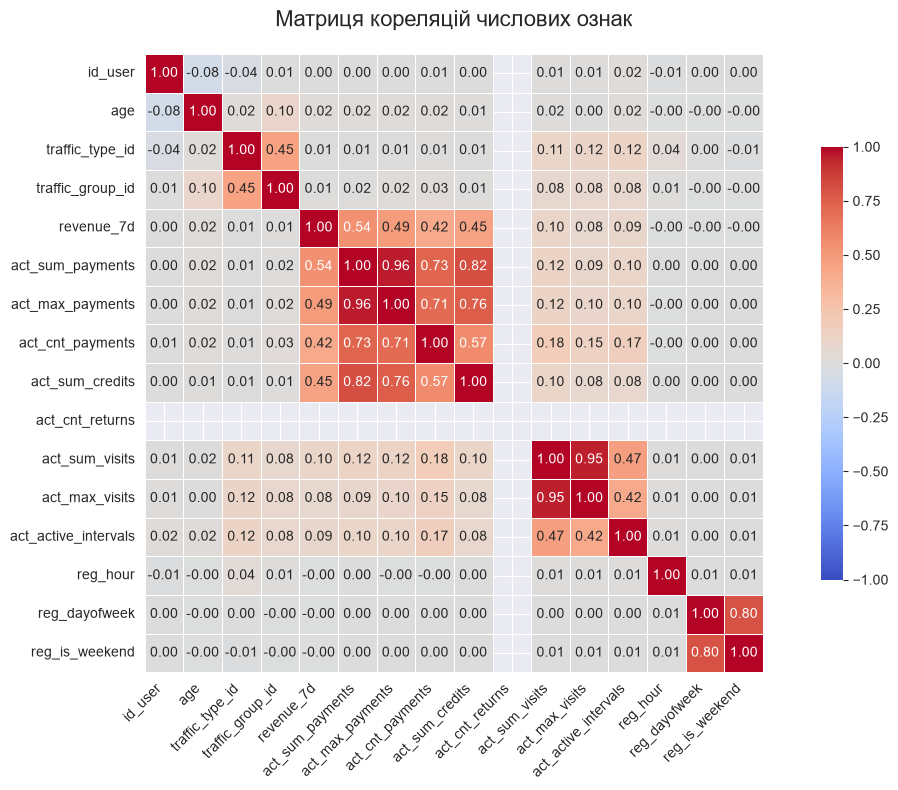

In [148]:
num_cols = df.select_dtypes(include=['number'])
corr = num_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7}
)

plt.title('Матриця кореляцій числових ознак', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [149]:
# Можна видалити цю колонку, бо вона містить константу і не несе якоїсь користі.
df['act_cnt_returns'].value_counts()

act_cnt_returns
0    1614200
Name: count, dtype: int64

--------------------
# Оцінка даних, вибір моделі та стратегії.

In [150]:
# Відсоток тих, хто нічого не купив (False) і тих, хто заплатив (True)
payer_percentage = (df['revenue_7d'] > 0).value_counts(normalize=True) * 100
print("Відсоток платників та неплатників:\n", payer_percentage)

Відсоток платників та неплатників:
 revenue_7d
False    97.869595
True      2.130405
Name: proportion, dtype: float64


Проблема нульової виручки: Оскільки близько 98% користувачів мають revenue_7d = 0, навчання єдиної моделі регресії на всьому датасеті призведе до зміщення прогнозів до нуля. Модель мінімізуватиме помилку за рахунок неплатників, ігноруючи цільовий сегмент.

Для вирішення цієї проблеми використаємо двохетапний підхід: 1) Класифікатор (LightGBM): оцінює ймовірність конверсії користувача в платника (чи заплатить взагалі). Обрано LightGBM завдяки високій швидкості навчання на великих об'ємах даних та нативній підтримці категоріальних ознак. 2) Регресор (LightGBM): Навчається виключно на сегменті платників.

------------------------
# Навчання моделей


In [151]:
X = df.drop(columns=['id_user', 'revenue_7d', 'act_cnt_returns'])
y = df['revenue_7d']

# shuffle=False зберігає хронологію (дані відсортовані за timestamp_reg)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
y_bin_train = y_train.gt(0).astype(int)
y_bin_test  = y_test.gt(0).astype(int)

print(f"Тренувальна вибірка: {X_train.shape[0]} рядків")
print(f"Тестова вибірка:     {X_test.shape[0]} рядків")
print(f"Платників у train:   {y_bin_train.sum()} ({y_bin_train.mean()*100:.1f}%)")
print(f"Платників у test:    {y_bin_test.sum()}  ({y_bin_test.mean()*100:.1f}%)")

# TimeSeriesSplit — CV без заглядання в майбутнє
tscv = TimeSeriesSplit(n_splits=3)

Тренувальна вибірка: 1291360 рядків
Тестова вибірка:     322840 рядків
Платників у train:   28093 (2.2%)
Платників у test:    6296  (2.0%)


In [152]:
clf_base = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

param_grid_clf = {
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63],
    'min_child_samples': [50, 100],
    'scale_pos_weight': [10, 30, 48]
}

grid_clf = GridSearchCV(
    estimator=clf_base,
    param_grid=param_grid_clf,
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

grid_clf.fit(X_train, y_bin_train)

print(f"Найкращі параметри Класифікатора: {grid_clf.best_params_}")
p_payer_test = grid_clf.best_estimator_.predict_proba(X_test)[:, 1]

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 28093, number of negative: 1263267
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3869
[LightGBM] [Info] Number of data points in the train set: 1291360, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.021755 -> initscore=-3.805936
[LightGBM] [Info] Start training from score -3.805936
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [153]:
payer_mask_train = y_train > 0
X_train_payers = X_train[payer_mask_train]
y_train_payers = y_train[payer_mask_train]

# Логарифмуємо таргет — це стабілізує дисперсію і допомагає моделі
y_train_payers_log = np.log1p(y_train_payers)

reg_base = LGBMRegressor(
    objective = 'regression',
    random_state = 42,
    n_jobs = -1
)

param_grid_reg = {
    'max_depth': [3, 4, 5],
    'num_leaves': [7, 15, 31],
    'min_child_samples': [50, 100, 200],
    'reg_lambda': [0.0, 1.0, 10.0]
}

grid_reg = GridSearchCV(
    estimator = reg_base,
    param_grid = param_grid_reg,
    scoring = 'neg_mean_absolute_error',
    cv = tscv,
    verbose = 1,
    n_jobs = -1
)

# Навчаємо на ЛОГАРИФМОВАНИХ значеннях виручки
grid_reg.fit(X_train_payers, y_train_payers_log)
print(f"Найкращі параметри Регресора: {grid_reg.best_params_}")

# Прогнозуємо на тесті та повертаємо з log
predicted_amount_test_log = grid_reg.best_estimator_.predict(X_test)
predicted_amount_test     = np.expm1(predicted_amount_test_log).clip(min=0)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2296
[LightGBM] [Info] Number of data points in the train set: 28093, number of used features: 20
[LightGBM] [Info] Start training from score 2.506111
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [154]:
# Фінальний прогноз = P(заплатить) * E(скільки заплатить)
# Математичне очікування виручки для кожного юзера
proba = grid_clf.best_estimator_.predict_proba(X_test)[:, 1]
pred_reg = predicted_amount_test
final_pred = proba * pred_reg

___________________________
# Оцінка моделей

**Класифікатор(чи заплатить користувач):**
Accuracy тут не підходить — при дисбалансі 98/2% модель, яка завжди передбачає "не платник", дасть 98% accuracy і буде марною. Тому:

* ROC-AUC — показує наскільки добре модель ранжує платників вище за неплатників, незалежно від порогу. Корисний для загальної оцінки якості.
* PR-AUC (Precision-Recall Curve) — більш інформативний при сильному дисбалансі класів, бо фокусується саме на меншому класі (платниках). ROC-AUC може виглядати оптимістично навіть при поганій якості.

**Регресор (скільки заплатить):**

* MAE — інтерпретується в доларах, стійкий до викидів (великих платежів "китів"). Зручний для бізнесу: "в середньому помиляємось на $X".
* RMSE — чутливий до великих помилок, тому показує чи модель сильно промахується по "китах".
* R² тут не є основною метрикою, бо при великій кількості нулів у тестовій вибірці може давати викривлену картину.

ROC-AUC: 0.9566
PR-AUC:  0.8046

Classification Report:
              precision    recall  f1-score   support

  Не платник       0.99      0.99      0.99    316544
     Платник       0.73      0.75      0.74      6296

    accuracy                           0.99    322840
   macro avg       0.86      0.87      0.87    322840
weighted avg       0.99      0.99      0.99    322840



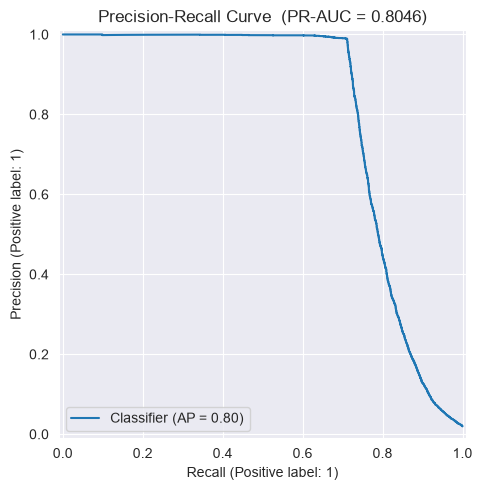

In [155]:
# Оцінка Класифікатора
roc_auc = roc_auc_score(y_bin_test, p_payer_test)
print(f"ROC-AUC: {roc_auc:.4f}")

pr_auc = average_precision_score(y_bin_test, p_payer_test)
print(f"PR-AUC:  {pr_auc:.4f}")

y_pred_clf = (p_payer_test >= 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_bin_test, y_pred_clf, target_names=["Не платник", "Платник"]))

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_bin_test, p_payer_test, ax=ax)
ax.set_title(f"Precision-Recall Curve  (PR-AUC = {pr_auc:.4f})")
plt.tight_layout()
plt.show()

In [156]:
# Оцінка Регресора (тільки на платниках тестової вибірки)

payer_mask_test  = y_test > 0
y_true_payers    = y_test[payer_mask_test]
y_pred_payers    = predicted_amount_test[payer_mask_test]

mae = mean_absolute_error(y_true_payers, y_pred_payers)
rmse = np.sqrt(mean_squared_error(y_true_payers, y_pred_payers))
r2 = r2_score(y_true_payers, y_pred_payers)

print(f"MAE  (середня абс. помилка в $): {mae:.2f}")
print(f"RMSE (чутливий до викидів):      {rmse:.2f}")
print(f"R²   (тільки на платниках):       {r2:.4f}")

MAE  (середня абс. помилка в $): 33.10
RMSE (чутливий до викидів):      138.20
R²   (тільки на платниках):       0.4580


Фінальний MAE  (весь тест): 1.14
Фінальний RMSE (весь тест): 19.50


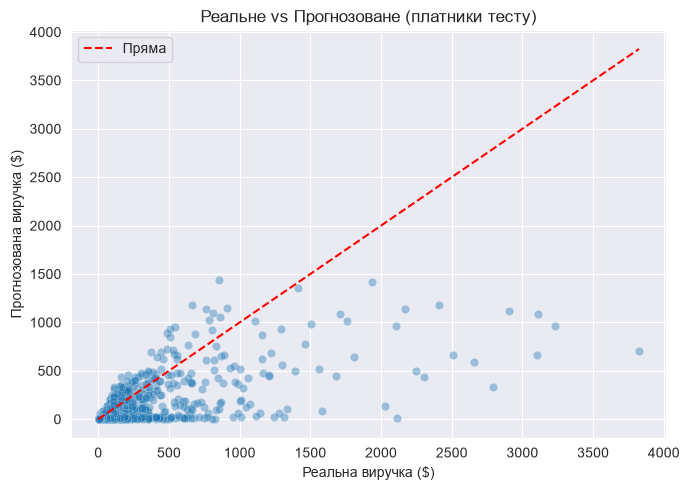

In [160]:
# Оцінка фінального прогнозу (на всій тестовій вибірці)

mae_final  = mean_absolute_error(y_test, final_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, final_pred))

print(f"Фінальний MAE  (весь тест): {mae_final:.2f}")
print(f"Фінальний RMSE (весь тест): {rmse_final:.2f}")

# Scatter: реальне vs прогнозоване (тільки на платниках — зручніше читати)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_true_payers, y_pred_payers, alpha=0.4, edgecolors="white", linewidths=0.3)
max_val = max(y_true_payers.max(), y_pred_payers.max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Пряма")
ax.set_xlabel("Реальна виручка ($)")
ax.set_ylabel("Прогнозована виручка ($)")
ax.set_title("Реальне vs Прогнозоване (платники тесту)")
ax.legend()
plt.tight_layout()
plt.show()

----------------------
# Feature Importance — LightGBM

LightGBM рахує важливість ознак за кількістю сплітів (splits) або сукупним приростом (gain). Використовуємо `gain` — він показує фактичний внесок у зменшення помилки.

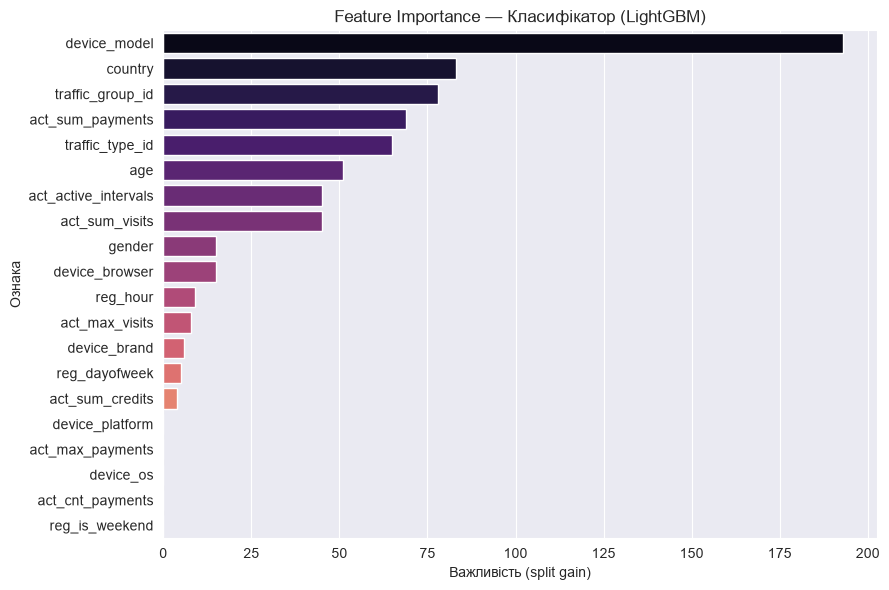

In [158]:
clf_best = grid_clf.best_estimator_
feature_names = X_train.columns.tolist()

importance_clf = pd.DataFrame({
    "feature": feature_names,
    "importance": clf_best.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_clf, x="importance", y="feature", hue="feature", palette="magma", legend=False)
plt.title("Feature Importance — Класифікатор (LightGBM)")
plt.xlabel("Важливість (split gain)")
plt.ylabel("Ознака")
plt.tight_layout()
plt.show()

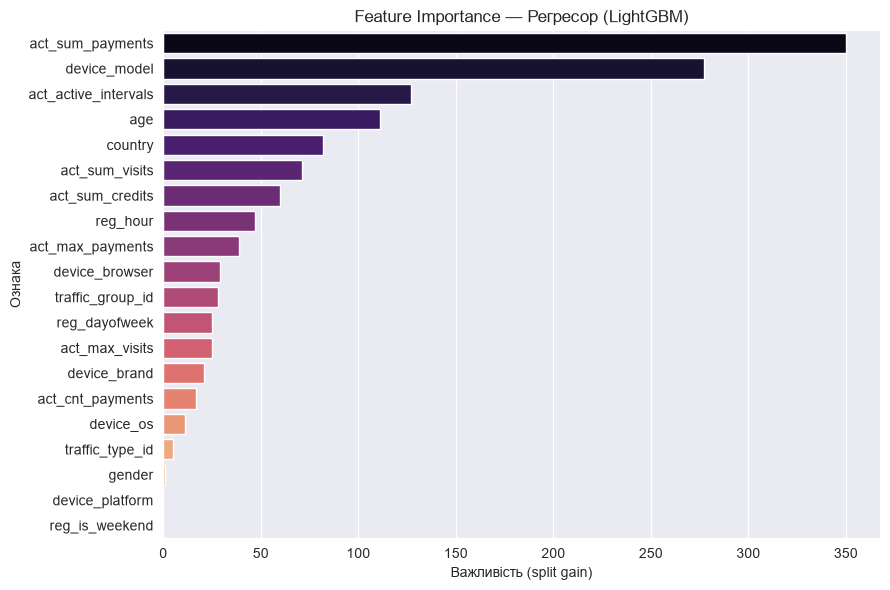

In [159]:
reg_best = grid_reg.best_estimator_

importance_reg = pd.DataFrame({
    "feature": feature_names,
    "importance": reg_best.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_reg, x="importance", y="feature", hue="feature", palette="magma", legend=False)
plt.title("Feature Importance — Регресор (LightGBM)")
plt.xlabel("Важливість (split gain)")
plt.ylabel("Ознака")
plt.tight_layout()
plt.show()

---------------
# Обмеження рішення

- Поведінкові дані є лише за перший день (4 інтервали по 6 годин) — це дуже вузьке вікно для прогнозу виручки за 7 днів.
- Платників лише ~2% від усієї вибірки, тому регресор навчається на дуже малій кількості прикладів, що підвищує ризик перенавчання.
- Регресор навчається тільки на платниках, але при інференсі отримує всіх користувачів — розподіл фіч може відрізнятись.

# Можливі покращення

- **Tweedie regression** як альтернатива двоетапному підходу — єдина модель, яка нативно моделює zero-inflated розподіл.
- Більше feature engineering: активність у конкретні інтервали (ранок/вечір), відношення `credits_spend / cnt_payments`.
- **Калібрування ймовірностей** класифікатора (`CalibratedClassifierCV`) для коректнішого математичного очікування при фінальному множенні `p * amount`.
- Додати **валідаційну вибірку** окремо від тестової (train / val / test), щоб підбір гіперпараметрів не «бачив» тест жодного разу.